# Notebook 02 — Preprocesamiento e Imputacion

**Proyecto de Grado — Maestria en Ciencia de Datos**
**Pontificia Universidad Javeriana Cali — Grupo 8**
**Autores:** Laura Garcia Salamanca, Daniel Sebastian Rosero Usama, Juan Villalobos Mora

---

## Estrategia de imputacion

La irradiancia solar exhibe dos regimenes fisicamente distintos:

**Regimen nocturno (horas 0-5 y 19-23):** RS = 0 por ausencia de radiacion solar.
La imputacion es determinista: cualquier NaN nocturno se asigna a 0.

**Regimen diurno (horas 6-18):** Se aplican tres tecnicas independientes.
Para la Tecnica 3 (Kalman) se estratifica por longitud de gap:
- Gap corto (<= 2 horas = 24 intervalos de 5 min): Filtro de Kalman.
  El EM tiene suficientes observaciones validas para estimar Q y R.
- Gap largo (> 2 horas o dia completo sin datos): Media climatologica
  hora x mes como fallback. Kalman con EM degenerara si no hay
  observaciones suficientes en el segmento diario.

**RS > 1400 W/m2:** Se conservan los 55 registros. El fenomeno de
cloud enhancement (realce por nubes) es fisicamente plausible en
zonas tropicales montanosas como Pasto. Umbral de descarte: 1600 W/m2.

## Contenido
1. Carga y configuracion
2. Clasificacion nocturno/diurno y correcciones previas
3. Imputacion nocturna (RS = 0)
4. Tecnica 1: Interpolacion lineal (limite 2h)
5. Tecnica 2: Media climatologica horaria
6. Tecnica 3: Kalman estratificado por longitud de gap
7. Integracion NASA POWER y variables derivadas
8. Comparacion de tecnicas
9. Guardado de datasets finales
10. Analisis descriptivo post-preprocesamiento


In [1]:
# 0. Importaciones
!pip install pandas numpy matplotlib seaborn pykalman scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import subprocess
import os
import warnings
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from pykalman import KalmanFilter

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# Umbral maximo de gap para aplicar Kalman (en numero de intervalos de 5 min)
# 24 intervalos x 5 min = 2 horas
KALMAN_GAP_MAX = 24

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
sns.set_palette('husl')
print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Umbral Kalman gap max:', KALMAN_GAP_MAX, 'intervalos =', KALMAN_GAP_MAX*5, 'min')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 6.5 MB/s eta 0:00:00
Librerias importadas: 2026-05-30 07:22:04
Umbral Kalman gap max: 24 intervalos = 120 min


In [2]:
# 1. Google Drive — deteccion automatica de rutas
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

resultado = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'Datos_2013_2026_completo.csv'],
    capture_output=True, text=True, timeout=60
)
rutas_csv = [r for r in resultado.stdout.strip().split('\n') if r]
if not rutas_csv:
    raise FileNotFoundError('No se encontro Datos_2013_2026_completo.csv')

RUTA_CSV = next(
    (r for r in rutas_csv if any(k in r for k in ['Maestr','Codigos','Trabajo'])),
    rutas_csv[0]
)
RUTA_BASE  = os.path.dirname(RUTA_CSV)
RUTA_DATOS = os.path.join(RUTA_BASE, 'datos')
RUTA_FIGS  = os.path.join(RUTA_BASE, 'figuras')
os.makedirs(RUTA_DATOS, exist_ok=True)
os.makedirs(RUTA_FIGS,  exist_ok=True)

resultado_nasa = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'nasa_power_pasto_2013_2026_horario.csv'],
    capture_output=True, text=True, timeout=60
)
rutas_nasa = [r for r in resultado_nasa.stdout.strip().split('\n') if r]
RUTA_NASA  = rutas_nasa[0] if rutas_nasa else None

print('RUTA_CSV   :', RUTA_CSV)
print('RUTA_DATOS :', RUTA_DATOS)
print('RUTA_NASA  :', RUTA_NASA)

Mounted at /content/drive
RUTA_CSV   : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/Datos_2013_2026_completo.csv
RUTA_DATOS : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos
RUTA_NASA  : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/nasa_power_pasto_2013_2026_horario.csv


In [3]:
# 1.1 Carga del dataset CESMAG
with open(RUTA_CSV, 'r', encoding='utf-8', errors='replace') as f:
    lineas = [f.readline().strip() for _ in range(3)]
cab = lineas[0]
SEP = ';' if cab.count(';') > cab.count(',') else ','
DEC = ',' if (SEP == ';' and ',' in lineas[1]) else '.'

print('Cargando dataset CESMAG...')
df_raw = pd.read_csv(
    RUTA_CSV, sep=SEP, decimal=DEC,
    parse_dates=['DateTime'], index_col='DateTime', encoding='utf-8'
)
df_raw.columns    = ['RS']
df_raw.index.name = 'timestamp'
df_raw.sort_index(inplace=True)
df_raw['RS'] = pd.to_numeric(df_raw['RS'], errors='coerce')

print(f'Registros : {len(df_raw):,}')
print(f'Faltantes : {df_raw["RS"].isnull().sum():,}  ({df_raw["RS"].isnull().mean()*100:.3f}%)')
print(f'Periodo   : {df_raw.index.min()} -> {df_raw.index.max()}')

Cargando dataset CESMAG...
Registros : 1,330,560
Faltantes : 225,244  (16.929%)
Periodo   : 2013-08-01 00:00:00 -> 2026-03-25 23:55:00


In [4]:
# 2. Clasificacion y correcciones previas
HORA_INICIO_DIURNO = 6
HORA_FIN_DIURNO    = 18

horas            = df_raw.index.hour
mascara_diurno   = (horas >= HORA_INICIO_DIURNO) & (horas <= HORA_FIN_DIURNO)
mascara_nocturno = ~mascara_diurno

# Correccion: RS < 0 -> 0
n_neg = (df_raw['RS'] < 0).sum()
df_raw.loc[df_raw['RS'] < 0, 'RS'] = 0.0

# Correccion: RS > 0 en horas nocturnas -> NaN para reclasificacion
n_noc_pos = ((df_raw['RS'] > 0) & mascara_nocturno).sum()
df_raw.loc[(df_raw['RS'] > 0) & mascara_nocturno, 'RS'] = np.nan

n_falt_noc  = df_raw.loc[mascara_nocturno,  'RS'].isnull().sum()
n_falt_diur = df_raw.loc[mascara_diurno,    'RS'].isnull().sum()

print('CORRECCIONES PREVIAS')
print(f'  RS < 0 -> 0                    : {n_neg:,}')
print(f'  RS > 0 nocturno -> NaN         : {n_noc_pos:,}')
print()
print('FALTANTES POR FRANJA')
print(f'  Nocturna  (0-5h, 19-23h) : {n_falt_noc:>7,}  ({n_falt_noc/mascara_nocturno.sum()*100:.2f}%)')
print(f'  Diurna    (6-18h)        : {n_falt_diur:>7,}  ({n_falt_diur/mascara_diurno.sum()*100:.2f}%)')

# Diagnostico de gaps diurnos por longitud
# Identificar bloques consecutivos de NaN diurnos
serie_diurna_diag = df_raw.loc[mascara_diurno, 'RS'].copy()
es_nan            = serie_diurna_diag.isnull().astype(int)
bloques           = (es_nan != es_nan.shift()).cumsum()
longitudes_gaps   = es_nan[es_nan == 1].groupby(bloques[es_nan == 1]).sum()

n_gaps_cortos = (longitudes_gaps <= KALMAN_GAP_MAX).sum()
n_gaps_largos = (longitudes_gaps >  KALMAN_GAP_MAX).sum()
pts_cortos    = longitudes_gaps[longitudes_gaps <= KALMAN_GAP_MAX].sum()
pts_largos    = longitudes_gaps[longitudes_gaps >  KALMAN_GAP_MAX].sum()

print()
print('DIAGNOSTICO DE GAPS DIURNOS')
print(f'  Gaps cortos (<={KALMAN_GAP_MAX} intervalos, <=2h) : {n_gaps_cortos:,}  ({pts_cortos:,} puntos -> Kalman)')
print(f'  Gaps largos (>{KALMAN_GAP_MAX}  intervalos, >2h)  : {n_gaps_largos:,}  ({pts_largos:,} puntos -> Media clim.)')

CORRECCIONES PREVIAS
  RS < 0 -> 0                    : 0
  RS > 0 nocturno -> NaN         : 105

FALTANTES POR FRANJA
  Nocturna  (0-5h, 19-23h) :   1,552  (0.25%)
  Diurna    (6-18h)        : 223,797  (31.05%)

DIAGNOSTICO DE GAPS DIURNOS
  Gaps cortos (<=24 intervalos, <=2h) : 67  (522 puntos -> Kalman)
  Gaps largos (>24  intervalos, >2h)  : 164  (223,275 puntos -> Media clim.)


In [5]:
# 3. Imputacion nocturna: RS = 0 (determinista)
df_base = df_raw.copy()
n_imp_noc = df_base.loc[mascara_nocturno, 'RS'].isnull().sum()
df_base.loc[mascara_nocturno, 'RS'] = df_base.loc[mascara_nocturno, 'RS'].fillna(0.0)

print('IMPUTACION NOCTURNA')
print(f'  Imputados con 0     : {n_imp_noc:,}')
print(f'  NaN nocturnos rest. : {df_base.loc[mascara_nocturno, "RS"].isnull().sum()}  (debe ser 0)')
print(f'  NaN diurnos rest.   : {df_base.loc[mascara_diurno, "RS"].isnull().sum():,}  (pendientes)')

IMPUTACION NOCTURNA
  Imputados con 0     : 1,552
  NaN nocturnos rest. : 0  (debe ser 0)
  NaN diurnos rest.   : 223,797  (pendientes)


In [6]:
# Precalcular media climatologica hora x mes (se reutiliza en T2 y como fallback de T3)
# Se calcula sobre los valores validos del dataset original (antes de cualquier imputacion)
df_aux = df_raw.copy()
df_aux['hora'] = df_aux.index.hour
df_aux['mes']  = df_aux.index.month

media_clim_df = (
    df_aux[df_aux['RS'].notna()]
    .groupby(['hora', 'mes'])['RS']
    .mean()
    .reset_index()
    .rename(columns={'RS': 'media_clim'})
)

# Convertir a dict para lookup rapido: (hora, mes) -> valor
dict_media_clim = {
    (row['hora'], row['mes']): row['media_clim']
    for _, row in media_clim_df.iterrows()
}

def imputar_con_media_clim(serie):
    """Imputa NaN usando la media climatologica hora x mes."""
    s = serie.copy()
    mascara = s.isnull()
    for ts in s.index[mascara]:
        clave = (ts.hour, ts.month)
        s.at[ts] = dict_media_clim.get(clave, 0.0)
    return s.clip(lower=0.0, upper=1600.0)

media_clim_df.to_csv(
    os.path.join(RUTA_DATOS, 'tabla_02_medias_climatologicas.csv'), index=False
)
print(f'Medias climatologicas calculadas: {len(media_clim_df)} combinaciones hora x mes')
print('Guardado: tabla_02_medias_climatologicas.csv')

Medias climatologicas calculadas: 288 combinaciones hora x mes
Guardado: tabla_02_medias_climatologicas.csv


In [7]:
# 4. Tecnica 1 — Interpolacion lineal con limite de 2 horas
#
# Fundamento: la interpolacion lineal estima valores faltantes asumiendo
# variacion proporcional al tiempo entre los puntos validos adyacentes.
# El parametro limit=24 restringe la interpolacion a gaps de hasta 2 horas
# (24 intervalos x 5 min). Para gaps mas largos, el valor queda NaN y
# se imputa con la media climatologica como fallback, evitando las
# mesetas artificiales observadas en la version anterior.

df_t1 = df_base.copy()

# Aplicar solo en franja diurna con limite de 24 intervalos
serie_diurna = df_t1.loc[mascara_diurno, 'RS'].copy()
serie_interp = serie_diurna.interpolate(
    method='time',
    limit=KALMAN_GAP_MAX,          # maximo 24 intervalos consecutivos
    limit_direction='both'
)
df_t1.loc[mascara_diurno, 'RS'] = serie_interp

# Fallback con media climatologica para gaps que superaron el limite
n_restantes_t1 = df_t1['RS'].isnull().sum()
if n_restantes_t1 > 0:
    df_t1.loc[:, 'RS'] = imputar_con_media_clim(df_t1['RS'])

df_t1['RS'] = df_t1['RS'].clip(lower=0.0, upper=1600.0)

print('TECNICA 1 — INTERPOLACION LINEAL (limite 2h)')
print(f'  Imputados por interpolacion   : {n_falt_diur - n_restantes_t1:,}')
print(f'  Imputados por media clim.     : {n_restantes_t1:,}')
print(f'  NaN restantes                 : {df_t1["RS"].isnull().sum()}  (debe ser 0)')
print(f'  Min / Max / Media RS          : {df_t1["RS"].min():.2f} / {df_t1["RS"].max():.2f} / {df_t1["RS"].mean():.4f} W/m2')

TECNICA 1 — INTERPOLACION LINEAL (limite 2h)
  Imputados por interpolacion   : 7,993
  Imputados por media clim.     : 215,804
  NaN restantes                 : 0  (debe ser 0)
  Min / Max / Media RS          : 0.00 / 1559.00 / 142.8036 W/m2


In [8]:
# 5. Tecnica 2 — Media climatologica horaria
#
# Fundamento: la media climatologica hora x mes captura la estacionalidad
# doble de la irradiancia (ciclo diario y variacion mensual) sin depender
# de los valores adyacentes. Es equivalente a usar el componente estacional
# de una descomposicion STL como valor de referencia. Robusta para gaps
# de cualquier longitud.

df_t2 = df_base.copy()
df_t2.loc[:, 'RS'] = imputar_con_media_clim(df_t2['RS'])
df_t2['RS'] = df_t2['RS'].clip(lower=0.0, upper=1600.0)

print('TECNICA 2 — MEDIA CLIMATOLOGICA HORARIA')
print(f'  NaN restantes : {df_t2["RS"].isnull().sum()}  (debe ser 0)')
print(f'  Min / Max / Media RS : {df_t2["RS"].min():.2f} / {df_t2["RS"].max():.2f} / {df_t2["RS"].mean():.4f} W/m2')

TECNICA 2 — MEDIA CLIMATOLOGICA HORARIA
  NaN restantes : 0  (debe ser 0)
  Min / Max / Media RS : 0.00 / 1559.00 / 142.6615 W/m2


In [9]:
# 6. Tecnica 3 — Filtro de Kalman estratificado por longitud de gap
#
# Fundamento: el filtro de Kalman es un estimador recursivo optimo para
# sistemas dinamicos lineales con ruido gaussiano. Modela RS como un
# proceso de estado latente con ecuaciones:
#
#   x_t = x_{t-1} + w_t    (paseo aleatorio, w_t ~ N(0,Q))
#   z_t = x_t + v_t        (observacion directa, v_t ~ N(0,R))
#
# Q y R se estiman por Expectation-Maximization (EM) sobre los valores
# observados del segmento. Para que el EM converja correctamente se
# requieren suficientes observaciones validas.
#
# ESTRATIFICACION:
# - Gap corto (<= 24 intervalos = 2h): suficientes puntos validos en el
#   dia para que el EM estime Q y R con fiabilidad. Se aplica Kalman
#   sobre el dia completo SOLO en franja diurna.
# - Gap largo (> 24 intervalos o dia sin datos): el EM no tiene
#   suficientes observaciones. Se usa media climatologica como fallback.
#
# CORRECCION RESPECTO A VERSION ANTERIOR:
# El segmento procesado por Kalman se restringe estrictamente a la
# franja diurna del dia (6-18h). Incluir horas nocturnas (RS = 0)
# contamina el EM y hace que Q y R converjan a valores casi nulos,
# produciendo estimaciones degeneradas cercanas a cero.

df_t3 = df_base.copy()

def kalman_impute_diurno(serie_diurna_dia):
    """
    Aplica Kalman a la franja diurna de un dia (solo horas 6-18).
    Sustituye unicamente los NaN originales; los valores observados
    no se modifican.

    Parametros:
    -----------
    serie_diurna_dia : pd.Series con indice temporal, solo horas 6-18

    Retorna:
    --------
    pd.Series con NaN imputados
    """
    valores = serie_diurna_dia.values.astype(float)
    n       = len(valores)

    # Si no hay ningun valor valido -> fallback a 0
    # (se reemplazara por media clim. en el paso siguiente)
    if np.all(np.isnan(valores)):
        return pd.Series(np.nan * np.ones(n), index=serie_diurna_dia.index)

    # Media de los valores observados -> estado inicial
    media_obs = np.nanmean(valores)
    var_obs   = np.nanvar(valores) if np.nanvar(valores) > 0 else 1.0

    kf = KalmanFilter(
        transition_matrices   = [[1]],
        observation_matrices  = [[1]],
        transition_covariance = [[var_obs * 0.1]],
        observation_covariance= [[var_obs * 0.5]],
        initial_state_mean    = [media_obs],
        initial_state_covariance = [[var_obs]],
        em_vars=['transition_covariance', 'observation_covariance']
    )

    obs = valores.reshape(-1, 1).copy()

    try:
        kf = kf.em(obs, n_iter=10)
        estados, _ = kf.smooth(obs)
        estimados  = estados.flatten()
    except Exception:
        # Si el EM falla, fallback a interpolacion lineal
        estimados = serie_diurna_dia.interpolate(
            method='time', limit_direction='both'
        ).values

    # Sustituir SOLO los NaN originales
    resultado = serie_diurna_dia.copy()
    nan_mask  = serie_diurna_dia.isnull()
    resultado[nan_mask] = estimados[nan_mask.values]

    return resultado.clip(lower=0.0, upper=1600.0)


# Identificar dias con gaps cortos en franja diurna
# Un dia es elegible para Kalman si su gap maximo diurno <= KALMAN_GAP_MAX
print('Clasificando dias por longitud de gap diurno...')

serie_diurna_base = df_t3.loc[mascara_diurno, 'RS'].copy()
fechas_unicas     = pd.Series(serie_diurna_base.index.date).unique()

dias_kalman      = set()
dias_media_clim  = set()

for fecha in fechas_unicas:
    seg = serie_diurna_base[serie_diurna_base.index.date == fecha]
    if seg.isnull().sum() == 0:
        continue  # dia completo, no requiere imputacion
    if seg.isnull().all():
        dias_media_clim.add(fecha)  # dia sin ningun dato diurno
        continue
    # Calcular longitud del gap mas largo del dia
    es_nan    = seg.isnull().astype(int)
    bloques   = (es_nan != es_nan.shift()).cumsum()
    gaps      = es_nan[es_nan == 1].groupby(bloques[es_nan == 1]).sum()
    gap_max   = gaps.max() if len(gaps) > 0 else 0

    if gap_max <= KALMAN_GAP_MAX:
        dias_kalman.add(fecha)
    else:
        dias_media_clim.add(fecha)

print(f'  Dias con Kalman      : {len(dias_kalman):,}')
print(f'  Dias con Media clim. : {len(dias_media_clim):,}')
print(f'  Dias sin faltantes   : {len(fechas_unicas) - len(dias_kalman) - len(dias_media_clim):,}')

Clasificando dias por longitud de gap diurno...
  Dias con Kalman      : 98
  Dias con Media clim. : 1,523
  Dias sin faltantes   : 2,999


In [11]:
# Aplicar Kalman a los dias elegibles
print('Aplicando Kalman a dias con gaps cortos...')

n_kalman_aplicados = 0
for i, fecha in enumerate(sorted(dias_kalman)):
    # Extraer SOLO la franja diurna del dia desde serie_diurna_base
    seg_diurno   = serie_diurna_base[serie_diurna_base.index.date == fecha]
    seg_imputado = kalman_impute_diurno(seg_diurno)
    df_t3.loc[seg_imputado.index, 'RS'] = seg_imputado.values
    n_kalman_aplicados += 1

    if n_kalman_aplicados % 200 == 0:
        print(f'  Dias procesados: {n_kalman_aplicados}/{len(dias_kalman)}')

print(f'  Kalman aplicado a {n_kalman_aplicados} dias.')

# Aplicar media climatologica a los dias con gaps largos o sin datos
print('Aplicando media climatologica a dias con gaps largos...')
nan_restantes_t3 = df_t3['RS'].isnull().sum()
if nan_restantes_t3 > 0:
    df_t3.loc[:, 'RS'] = imputar_con_media_clim(df_t3['RS'])

df_t3['RS'] = df_t3['RS'].clip(lower=0.0, upper=1600.0)

n_nan_t3_final = df_t3['RS'].isnull().sum()
print()
print('TECNICA 3 — FILTRO DE KALMAN (estratificado)')
print(f'  Dias con Kalman aplicado      : {len(dias_kalman):,}')
print(f'  Dias con Media clim. fallback : {len(dias_media_clim):,}')
print(f'  NaN restantes                 : {n_nan_t3_final}  (debe ser 0)')
print(f'  Min / Max / Media RS          : {df_t3["RS"].min():.2f} / {df_t3["RS"].max():.2f} / {df_t3["RS"].mean():.4f} W/m2')

Aplicando Kalman a dias con gaps cortos...
  Kalman aplicado a 98 dias.
Aplicando media climatologica a dias con gaps largos...

TECNICA 3 — FILTRO DE KALMAN (estratificado)
  Dias con Kalman aplicado      : 98
  Dias con Media clim. fallback : 1,523
  NaN restantes                 : 0  (debe ser 0)
  Min / Max / Media RS          : 0.00 / 1559.00 / 142.6934 W/m2


In [12]:
# 7. Integracion NASA POWER y variables derivadas

if RUTA_NASA is None:
    print('ADVERTENCIA: NASA POWER no encontrado. Solo variables temporales.')
    df_nasa_5 = None
else:
    print('Cargando NASA POWER...')
    df_nasa = pd.read_csv(RUTA_NASA, index_col='timestamp_utc', parse_dates=True)
    print(f'  Registros: {len(df_nasa):,} | Variables: {list(df_nasa.columns)}')

    # Interpolar de resolucion horaria a 5 minutos
    idx_5min  = df_t1.index
    df_nasa_5 = (
        df_nasa
        .reindex(df_nasa.index.union(idx_5min))
        .interpolate(method='time')
        .reindex(idx_5min)
        .ffill()
        .bfill()
    )
    print(f'  Interpolado a 5 min: {len(df_nasa_5):,} registros')
    print(f'  NaN tras interpolacion: {df_nasa_5.isnull().sum().sum():,}')

Cargando NASA POWER...
  Registros: 111,744 | Variables: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA', 'KT']
  Interpolado a 5 min: 1,330,560 registros
  NaN tras interpolacion: 0


In [13]:
# 7.1 Variables temporales ciclicas y derivadas
#
# Variables temporales ciclicas con codificacion sin/cos:
# Las variables periodicas (hora, mes, dia del anio) son ciclicas:
# la hora 23 es adyacente a la 0, diciembre a enero. Codificarlas
# como enteros introduce discontinuidades artificiales. La transformacion
# sin/cos proyecta cada variable sobre un circulo unitario preservando
# la continuidad y permitiendo al modelo capturar la periodicidad:
#
#   sin(2*pi*hora/24)  ,  cos(2*pi*hora/24)

def agregar_variables(df, df_nasa_5=None):
    d = df[['RS']].copy()

    # Variables temporales enteras
    d['hora']       = d.index.hour
    d['minuto']     = d.index.minute
    d['dia_semana'] = d.index.dayofweek
    d['dia_anio']   = d.index.dayofyear
    d['mes']        = d.index.month
    d['anio']       = d.index.year

    # Codificacion ciclica: hora del dia
    min_total     = d['hora'] * 60 + d['minuto']
    d['sin_hora'] = np.sin(2 * np.pi * min_total / (24 * 60))
    d['cos_hora'] = np.cos(2 * np.pi * min_total / (24 * 60))

    # Codificacion ciclica: dia del anio
    d['sin_dia_anio'] = np.sin(2 * np.pi * d['dia_anio'] / 365.25)
    d['cos_dia_anio'] = np.cos(2 * np.pi * d['dia_anio'] / 365.25)

    # Codificacion ciclica: mes
    d['sin_mes'] = np.sin(2 * np.pi * d['mes'] / 12)
    d['cos_mes'] = np.cos(2 * np.pi * d['mes'] / 12)

    # Indicador binario franja diurna
    d['es_diurno'] = ((d['hora'] >= HORA_INICIO_DIURNO) &
                      (d['hora'] <= HORA_FIN_DIURNO)).astype(int)

    # Variables NASA POWER
    if df_nasa_5 is not None:
        for col in df_nasa_5.columns:
            d[col] = df_nasa_5[col].values

        # Indice de claridad KT
        d['KT'] = np.where(
            d['CLRSKY_SFC_SW_DWN'] > 0,
            (d['ALLSKY_SFC_SW_DWN'] / d['CLRSKY_SFC_SW_DWN']).clip(0, 1.5),
            0.0
        )
    return d

print('Agregando variables a los tres datasets...')
df_t1 = agregar_variables(df_t1, df_nasa_5 if RUTA_NASA else None)
df_t2 = agregar_variables(df_t2, df_nasa_5 if RUTA_NASA else None)
df_t3 = agregar_variables(df_t3, df_nasa_5 if RUTA_NASA else None)

print('Variables finales:', df_t1.columns.tolist())
print('Total variables  :', df_t1.shape[1])

Agregando variables a los tres datasets...
Variables finales: ['RS', 'hora', 'minuto', 'dia_semana', 'dia_anio', 'mes', 'anio', 'sin_hora', 'cos_hora', 'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes', 'es_diurno', 'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA', 'KT']
Total variables  : 24


In [14]:
# 8. Comparacion de tecnicas
idx_falt_diur = df_raw.index[df_raw['RS'].isnull() & mascara_diurno]

vals_t1 = df_t1.loc[idx_falt_diur, 'RS']
vals_t2 = df_t2.loc[idx_falt_diur, 'RS']
vals_t3 = df_t3.loc[idx_falt_diur, 'RS']

comp = pd.DataFrame({
    'T1_Interpolacion': vals_t1,
    'T2_Media_Clim'   : vals_t2,
    'T3_Kalman'       : vals_t3,
})

print('COMPARACION EN PUNTOS ORIGINALMENTE FALTANTES (diurnos)')
print(f'N puntos: {len(idx_falt_diur):,}')
print()
print(comp.describe().round(2).to_string())
print()
print('Diferencia absoluta media entre tecnicas:')
print(f'  |T1 - T2|: {(vals_t1 - vals_t2).abs().mean():.4f} W/m2')
print(f'  |T1 - T3|: {(vals_t1 - vals_t3).abs().mean():.4f} W/m2')
print(f'  |T2 - T3|: {(vals_t2 - vals_t3).abs().mean():.4f} W/m2')

comp.to_csv(os.path.join(RUTA_DATOS, 'tabla_02_comparacion_imputaciones.csv'))

COMPARACION EN PUNTOS ORIGINALMENTE FALTANTES (diurnos)
N puntos: 223,797

       T1_Interpolacion  T2_Media_Clim  T3_Kalman
count         223797.00      223797.00  223797.00
mean             263.62         262.78     262.97
std              170.73         166.62     166.79
min                0.00           0.15       0.00
25%              100.48         100.48     100.48
50%              277.14         277.14     277.14
75%              409.99         409.99     409.99
max             1362.17         539.08    1186.54

Diferencia absoluta media entre tecnicas:
  |T1 - T2|: 5.3158 W/m2
  |T1 - T3|: 4.7898 W/m2
  |T2 - T3|: 0.5337 W/m2


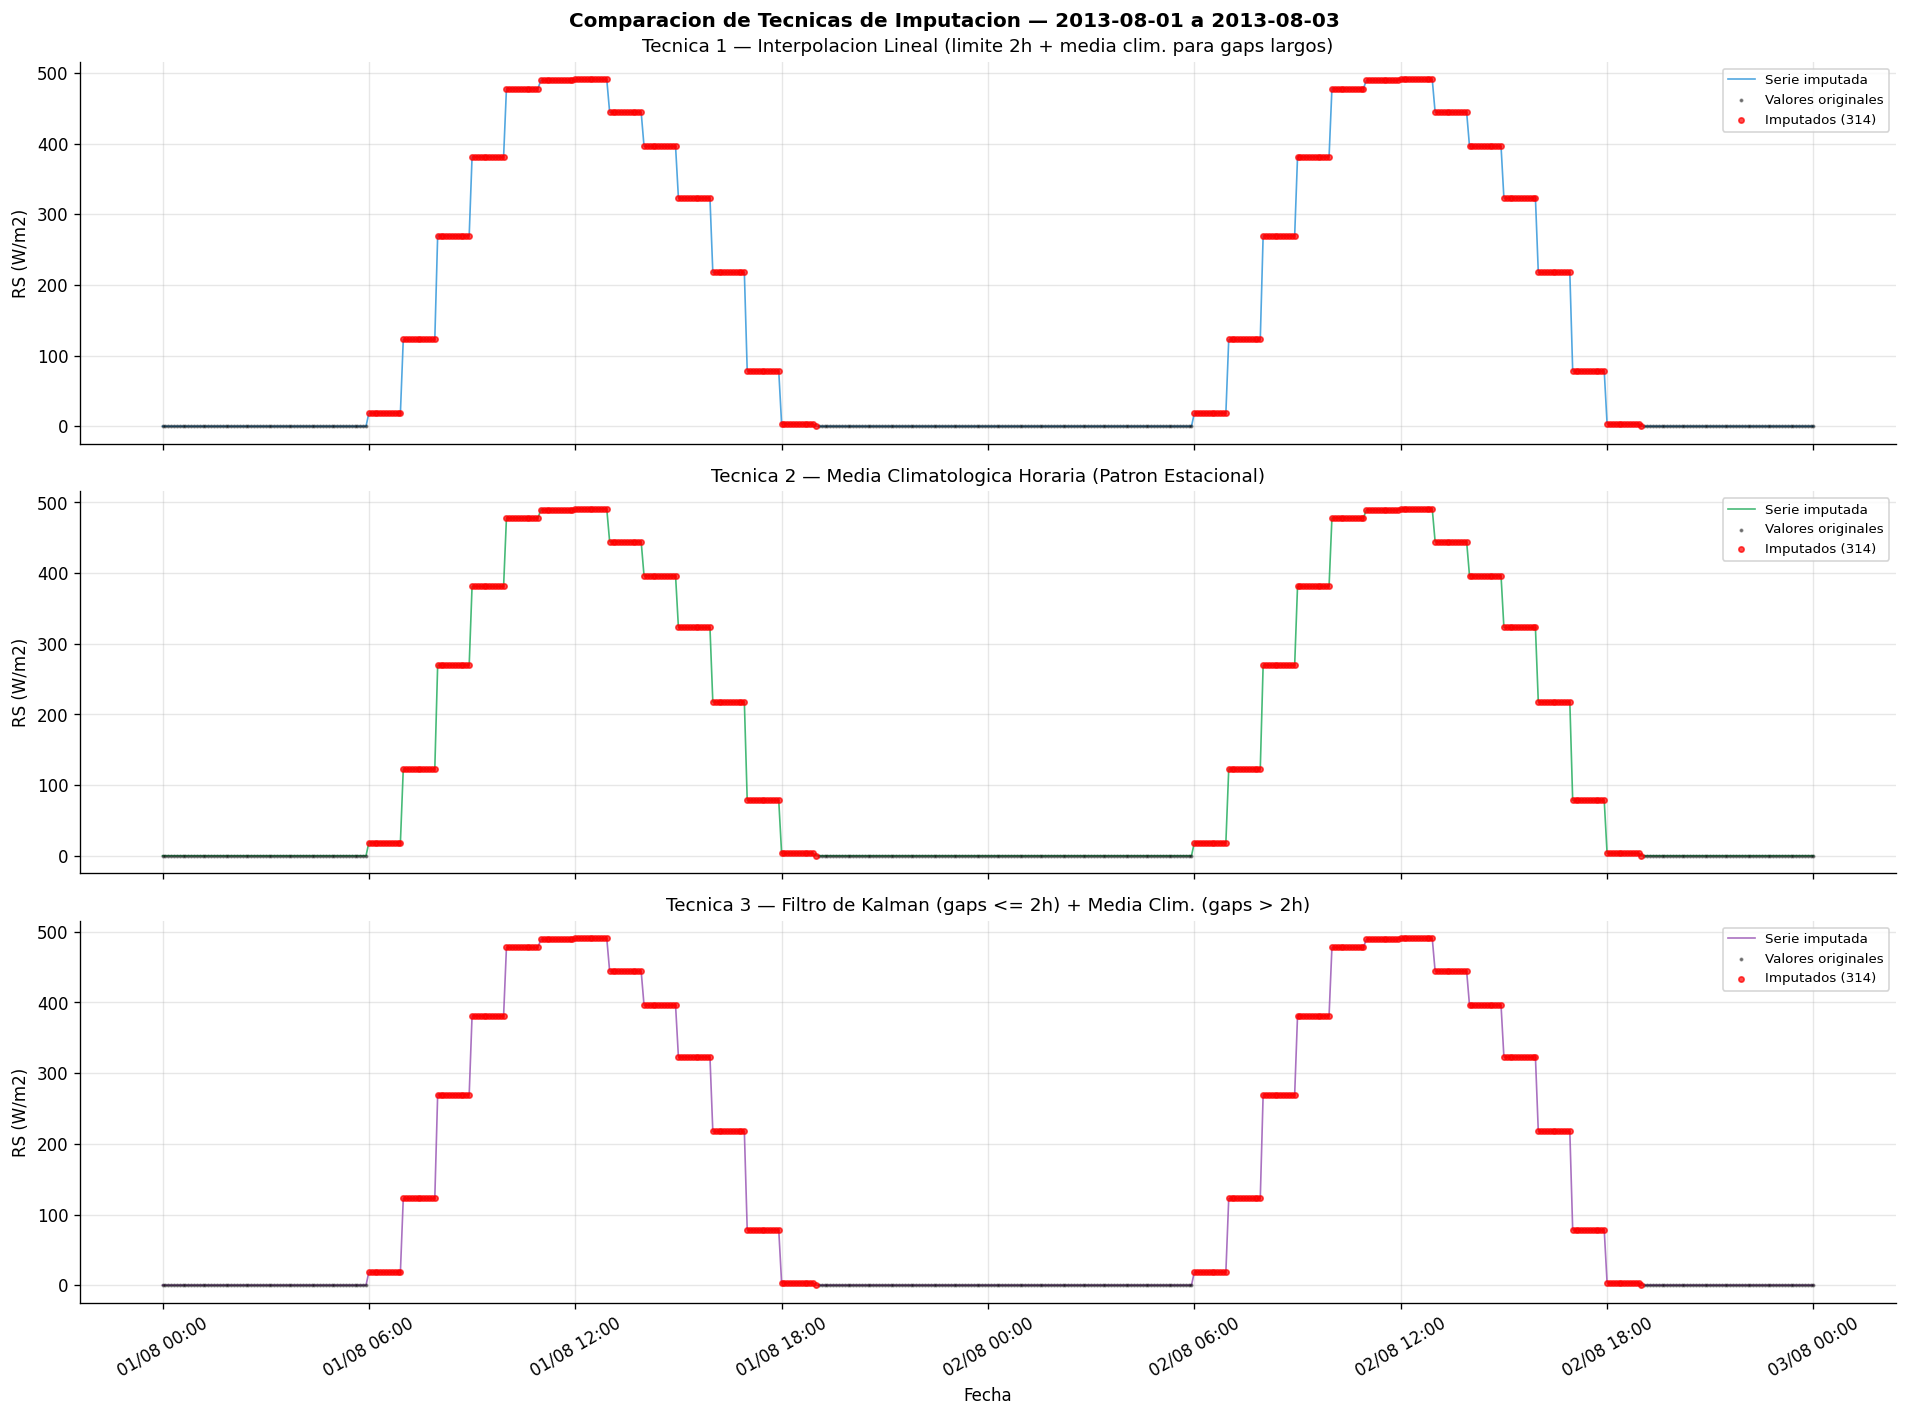

Guardado: fig_02a_comparacion_imputaciones.png


In [15]:
# Visualizacion comparativa en una ventana de 3 dias con faltantes diurnos
primer_dia = idx_falt_diur[0].normalize()
fecha_fin  = primer_dia + pd.Timedelta(days=2)
mask_viz   = (df_raw.index >= primer_dia) & (df_raw.index <= fecha_fin)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(
    f'Comparacion de Tecnicas de Imputacion — {primer_dia.date()} a {fecha_fin.date()}',
    fontsize=12, fontweight='bold'
)

titulos  = [
    'Tecnica 1 — Interpolacion Lineal (limite 2h + media clim. para gaps largos)',
    'Tecnica 2 — Media Climatologica Horaria (Patron Estacional)',
    'Tecnica 3 — Filtro de Kalman (gaps <= 2h) + Media Clim. (gaps > 2h)'
]
colores  = ['#3498DB', '#27AE60', '#9B59B6']
datasets = [df_t1, df_t2, df_t3]

for ax, df_tx, titulo, color in zip(axes, datasets, titulos, colores):
    rs_orig = df_raw.loc[mask_viz, 'RS']
    rs_imp  = df_tx.loc[mask_viz, 'RS']
    nan_viz = rs_orig.isnull()

    ax.plot(rs_imp.index, rs_imp.values,
            color=color, lw=1.0, alpha=0.85, label='Serie imputada')
    ax.scatter(rs_orig.dropna().index, rs_orig.dropna().values,
               color='black', s=2, alpha=0.4, label='Valores originales', zorder=4)
    ax.scatter(rs_imp[nan_viz].index, rs_imp[nan_viz].values,
               color='red', s=10, zorder=5, alpha=0.7,
               label=f'Imputados ({nan_viz.sum()})')
    ax.set_title(titulo)
    ax.set_ylabel('RS (W/m2)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_02a_comparacion_imputaciones.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_02a_comparacion_imputaciones.png')

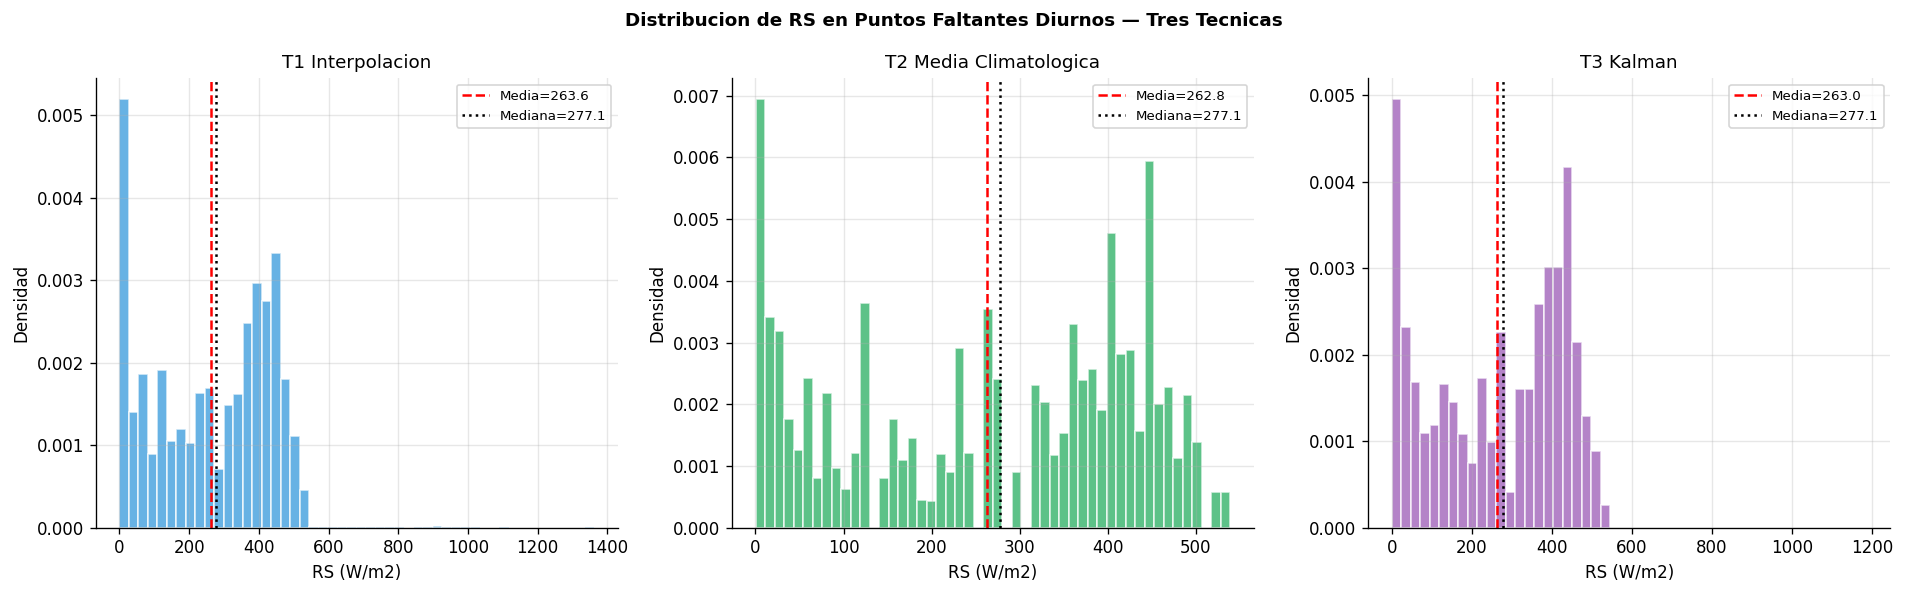

Guardado: fig_02b_distribucion_imputados.png


In [16]:
# Distribucion de valores imputados
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribucion de RS en Puntos Faltantes Diurnos — Tres Tecnicas',
             fontsize=11, fontweight='bold')

for ax, vals, etiq, color in zip(
    axes,
    [vals_t1, vals_t2, vals_t3],
    ['T1 Interpolacion', 'T2 Media Climatologica', 'T3 Kalman'],
    ['#3498DB', '#27AE60', '#9B59B6']
):
    v = vals.dropna()
    ax.hist(v, bins=50, color=color, alpha=0.75, edgecolor='white', density=True)
    ax.axvline(v.mean(),   color='red',   lw=1.5, ls='--', label=f'Media={v.mean():.1f}')
    ax.axvline(v.median(), color='black', lw=1.5, ls=':',  label=f'Mediana={v.median():.1f}')
    ax.set_title(etiq)
    ax.set_xlabel('RS (W/m2)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_02b_distribucion_imputados.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_02b_distribucion_imputados.png')

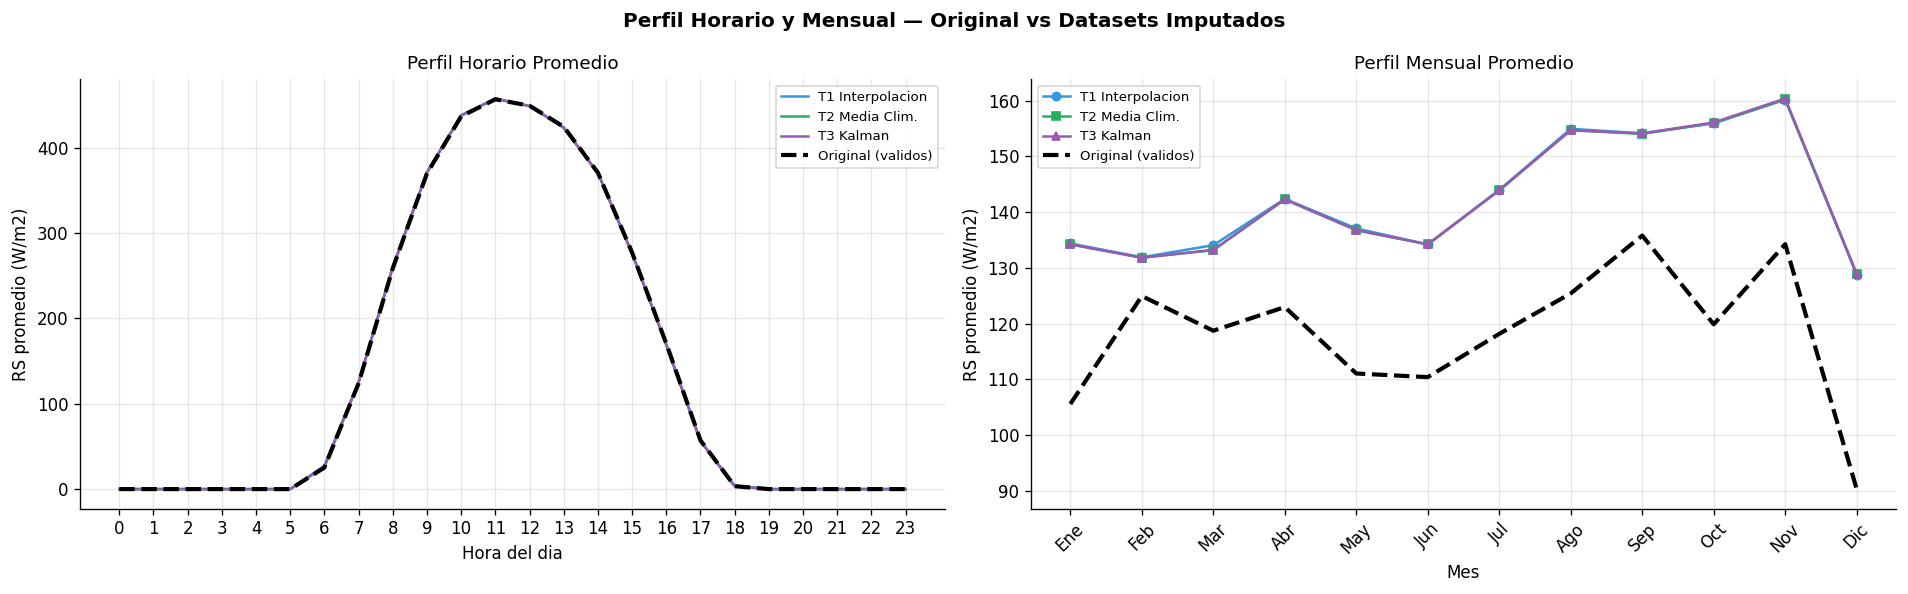

Guardado: fig_02c_perfil_post_imputacion.png


In [17]:
# Perfil horario y mensual: original vs tres datasets
mes_etiq = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Perfil Horario y Mensual — Original vs Datasets Imputados',
             fontsize=12, fontweight='bold')

ph_orig = df_raw['RS'].groupby(df_raw.index.hour).mean()
pm_orig = df_raw['RS'].groupby(df_raw.index.month).mean()

for df_tx, etiq, color, mk in zip(
    [df_t1, df_t2, df_t3],
    ['T1 Interpolacion', 'T2 Media Clim.', 'T3 Kalman'],
    ['#3498DB', '#27AE60', '#9B59B6'],
    ['o', 's', '^']
):
    ph = df_tx['RS'].groupby(df_tx.index.hour).mean()
    pm = df_tx['RS'].groupby(df_tx.index.month).mean()
    axes[0].plot(ph.index, ph.values, color=color, lw=1.5, label=etiq)
    axes[1].plot(pm.index, pm.values, color=color, lw=1.5, marker=mk, ms=5, label=etiq)

axes[0].plot(ph_orig.index, ph_orig.values, 'k--', lw=2.5, label='Original (validos)', zorder=5)
axes[0].set_title('Perfil Horario Promedio')
axes[0].set_xlabel('Hora del dia')
axes[0].set_ylabel('RS promedio (W/m2)')
axes[0].set_xticks(range(0, 24))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(pm_orig.index, pm_orig.values, 'k--', lw=2.5, label='Original (validos)', zorder=5)
axes[1].set_title('Perfil Mensual Promedio')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('RS promedio (W/m2)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(mes_etiq, rotation=45)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_02c_perfil_post_imputacion.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_02c_perfil_post_imputacion.png')

In [18]:
# 9. Guardado de los tres datasets finales
print('GUARDANDO DATASETS FINALES')
print('=' * 55)

for nombre, df_tx in [('interpolacion', df_t1), ('media_clim', df_t2), ('kalman', df_t3)]:
    n_nan = df_tx['RS'].isnull().sum()
    n_neg = (df_tx['RS'] < 0).sum()
    n_sup = (df_tx['RS'] > 1600).sum()

    assert n_nan == 0, f'ERROR: {nombre} tiene {n_nan} NaN'
    assert n_neg == 0, f'ERROR: {nombre} tiene {n_neg} valores negativos'
    assert n_sup == 0, f'ERROR: {nombre} tiene {n_sup} valores > 1600'

    ruta = os.path.join(RUTA_DATOS, f'dataset_final_{nombre}.csv')
    df_tx.to_csv(ruta)
    tam  = os.path.getsize(ruta) / 1024 / 1024
    print(f'  dataset_final_{nombre}.csv')
    print(f'    Registros : {len(df_tx):,} | Variables: {df_tx.shape[1]} | NaN: 0 | Tamano: {tam:.2f} MB')
    print()

GUARDANDO DATASETS FINALES
  dataset_final_interpolacion.csv
    Registros : 1,330,560 | Variables: 24 | NaN: 0 | Tamano: 351.60 MB

  dataset_final_media_clim.csv
    Registros : 1,330,560 | Variables: 24 | NaN: 0 | Tamano: 351.61 MB

  dataset_final_kalman.csv
    Registros : 1,330,560 | Variables: 24 | NaN: 0 | Tamano: 351.60 MB



In [19]:
# 10. Analisis descriptivo post-preprocesamiento
rs_orig = df_raw['RS'].dropna()

def stats(s):
    return [len(s), s.min(), s.max(), s.mean(), s.median(), s.std(), s.skew(), s.kurtosis()]

resumen = pd.DataFrame({
    'Original_validos': stats(rs_orig),
    'T1_Interpolacion': stats(df_t1['RS']),
    'T2_Media_Clim'   : stats(df_t2['RS']),
    'T3_Kalman'       : stats(df_t3['RS']),
}, index=['N','Min','Max','Media','Mediana','Std','Asimetria','Curtosis'])

print('ESTADISTICAS DESCRIPTIVAS POST-PREPROCESAMIENTO')
print('=' * 60)
print(resumen.round(4).to_string())
resumen.to_csv(os.path.join(RUTA_DATOS, 'tabla_02_desc_post_preprocesamiento.csv'))

print('\n' + '=' * 65)
print('RESUMEN FINAL — NOTEBOOK 02 PREPROCESAMIENTO')
print('=' * 65)
print(f'''
DATASETS GENERADOS
  dataset_final_interpolacion.csv  — T1: Interpolacion lineal (lim. 2h)
  dataset_final_media_clim.csv     — T2: Media climatologica hora x mes
  dataset_final_kalman.csv         — T3: Kalman (gaps<=2h) + Media clim.

CARACTERISTICAS COMUNES
  Registros  : {len(df_t1):,}
  Variables  : {df_t1.shape[1]}
  NaN en RS  : 0
  RS < 0     : 0
  RS > 1600  : 0

ESTRATEGIA DE IMPUTACION
  Nocturna (0-5h, 19-23h) : RS = 0  (determinista)
  Diurna T1               : Interpolacion lineal limite 2h + media clim.
  Diurna T2               : Media climatologica hora x mes (todos los gaps)
  Diurna T3               : Kalman (gap<=2h) + media clim. (gap>2h)

RS > 1400 W/m2 : conservados (cloud enhancement, Pasto zona tropical)
''')

print('Archivos en datos/:')
for f in sorted(os.listdir(RUTA_DATOS)):
    tam = os.path.getsize(os.path.join(RUTA_DATOS, f)) / 1024 / 1024
    print(f'  {f:<50} ({tam:.2f} MB)')

print('\nNotebook 02 completado.')
print('Siguiente: 03_eda_post_preprocesamiento.ipynb')

ESTADISTICAS DESCRIPTIVAS POST-PREPROCESAMIENTO
           Original_validos  T1_Interpolacion  T2_Media_Clim     T3_Kalman
N              1.105211e+06      1.330560e+06   1.330560e+06  1.330560e+06
Min            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Max            1.559000e+03      1.559000e+03   1.559000e+03  1.559000e+03
Media          1.185392e+02      1.428036e+02   1.426615e+02  1.426934e+02
Mediana        0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Std            2.225086e+02      2.213497e+02   2.207451e+02  2.207837e+02
Asimetria      2.409000e+00      1.943500e+00   1.937100e+00  1.937400e+00
Curtosis       6.092500e+00      4.213800e+00   4.196500e+00  4.197200e+00

RESUMEN FINAL — NOTEBOOK 02 PREPROCESAMIENTO

DATASETS GENERADOS
  dataset_final_interpolacion.csv  — T1: Interpolacion lineal (lim. 2h)
  dataset_final_media_clim.csv     — T2: Media climatologica hora x mes
  dataset_final_kalman.csv         — T3: Kalman (gaps<=2h) + Media 